## 2.1 Exploratory Analysis

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
# Load the dataset
data = pd.read_csv('transformer_data.csv')

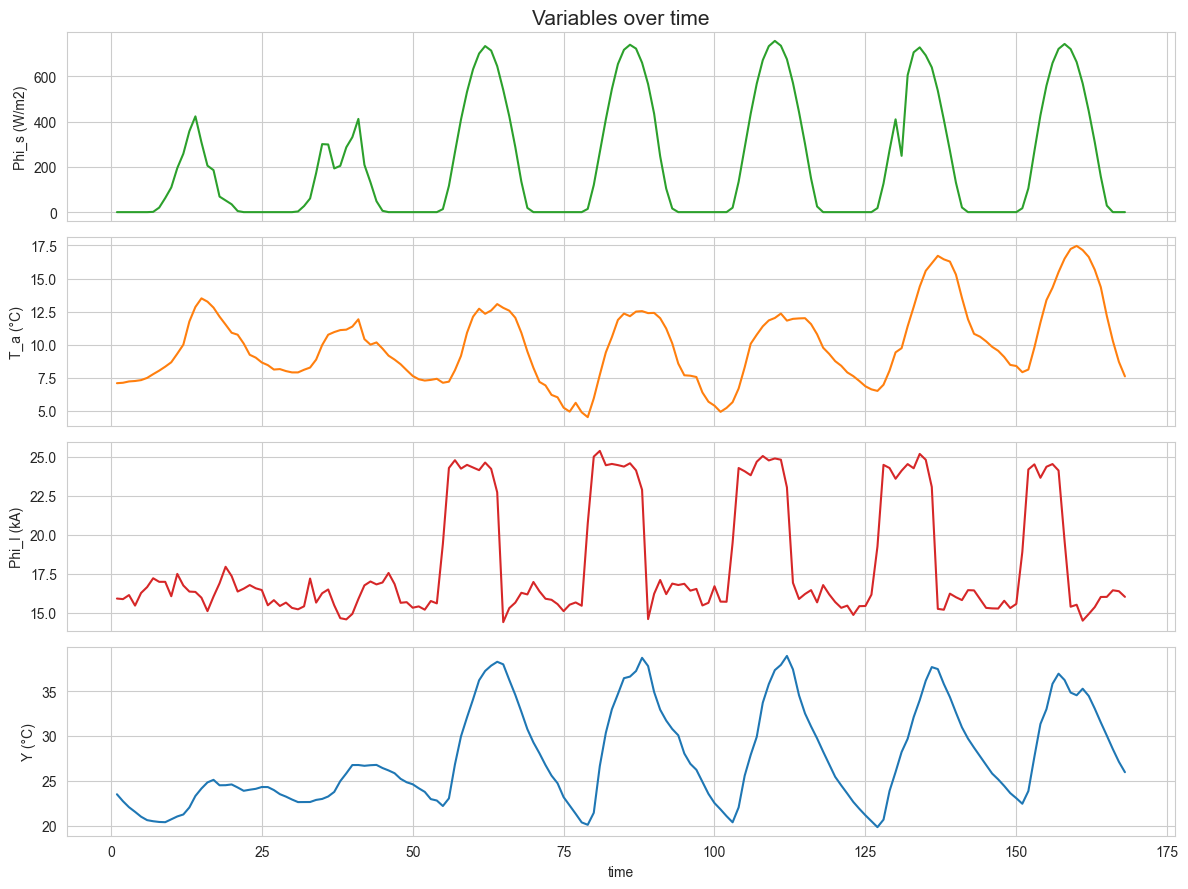

In [27]:
# Plot the variables in four stacked panels with shared time axis
sns.set_style('whitegrid')
fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)

axes[0].plot(data['time'], data['S'], color='C2')
axes[0].set_ylabel('Phi_s (W/m2)')
axes[0].set_title('Variables over time', fontsize=15)

axes[1].plot(data['time'], data['Ta'], color='C1')
axes[1].set_ylabel('T_a (°C)')

axes[2].plot(data['time'], data['I'], color='C3')
axes[2].set_ylabel('Phi_I (kA)')

axes[3].plot(data['time'], data['Y'], color='C0')
axes[3].set_ylabel('Y (°C)')
axes[3].set_xlabel('time')

plt.tight_layout()
plt.show()

## 2.2 Estimate a 1-dimensional state-space model

The model is:

$$X_{t+1} = A X_t + B u_t + G e_{1,t}, \quad e_{1,t} \sim \mathcal{N}(0,1)$$
$$Y_t = C X_t + e_{2,t}, \quad e_{2,t} \sim \mathcal{N}(0, \sigma_y^2)$$

where $u_t = [T_{a,t},\, \Phi_{s,t},\, \Phi_{I,t}]^T$. With $C = 1$ (direct observation of state), the parameters to estimate are $A$, $B \in \mathbb{R}^{1\times3}$, $G$, and $\sigma_y$.

In [24]:
from scipy.stats import probplot

def kf_filter(par, Y, U):
    """
    Kalman filter for diagnostics.
    par = [A, B1, B2, B3, G, sigma_y]  — same layout as R's estimate_dt.
    Returns innovations, innovation variances, and filtered states.
    """
    A, B, G, sigma_y = par[0], par[1:4], par[4], par[5]
    Q = G**2        # system noise variance
    R = sigma_y**2  # observation noise variance

    T = len(Y)
    x, P = float(Y[0]), 10.0
    innovations, S_vals, x_filt = [], [], []

    for t in range(T):
        x_pred = A * x + float(np.dot(B, U[t]))
        P_pred = A**2 * P + Q
        innov  = float(Y[t]) - x_pred
        S      = P_pred + R
        K      = P_pred / S
        x      = x_pred + K * innov
        P      = (1.0 - K) * P_pred
        innovations.append(innov)
        S_vals.append(S)
        x_filt.append(x)

    return np.array(innovations), np.array(S_vals), np.array(x_filt)

In [25]:
import os

# Windows fix: rpy2 needs R's bin directory on PATH to load R's DLLs (stats.dll etc.)
os.environ['R_HOME'] = r'C:\Program Files\R\R-4.5.3'
os.environ['PATH']   = r'C:\Program Files\R\R-4.5.3\bin\x64;' + os.environ['PATH']

import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter

# --- Prepare data ---
Y = data['Y'].values
U = data[['Ta', 'S', 'I']].values

# Source the R helper (path relative to this notebook's working directory)
r_script = os.path.join(os.getcwd(), 'functions_chant', 'functions_exercise2.R').replace('\\', '/')
ro.r(f'source("{r_script}")')

# Convert pandas DataFrame → R data.frame
with localconverter(ro.default_converter + pandas2ri.converter):
    r_df = ro.conversion.py2rpy(data[['Y', 'Ta', 'S', 'I']])
ro.globalenv['r_df'] = r_df

# Estimate via R's estimate_dt (L-BFGS-B)
# par = c(A, B1(Ta), B2(S), B3(I), G, sigma_y)
# Bounds are physically motivated:
#   A    in [0.5, 1)    — stationary, persistent temperature process
#   B    in [-5,  5]    — input effects (sign-unconstrained)
#   G    in [0.01, 10]  — system noise scale > 0
#   σ_y  in [0.05, 10]  — sensor noise ≥ ~0.05 °C
ro.r('''
start_par <- c(0.95,  0.04,  1e-4, 1e-1, 0.5,  0.5)
lower_b   <- c(0.50, -5.00, -5.00, -5.0, 0.01, 0.05)
upper_b   <- c(0.9999, 5.0,  5.00,  5.0, 10.0, 10.0)
fit_r <- estimate_dt(start_par, r_df, lower = lower_b, upper = upper_b)
''')

par_hat     = np.array(list(ro.r('fit_r$par')))
A_hat       = par_hat[0]
B_hat       = par_hat[1:4]
G_hat       = par_hat[4]
sigma_y_hat = par_hat[5]

logL  = -float(ro.r('fit_r$value')[0])
k     = len(par_hat)
n_obs = len(Y)
AIC   = 2*k - 2*logL
BIC   = k*np.log(n_obs) - 2*logL

print("Estimated parameters (via R kf_logLik_dt / L-BFGS-B):")
print(f"  A        = {A_hat:.6f}   (state persistence)")
print(f"  B (Ta)   = {B_hat[0]:.6f}   (ambient temperature)")
print(f"  B (S)    = {B_hat[1]:.6f}   (solar irradiance)")
print(f"  B (I)    = {B_hat[2]:.6f}   (load current)")
print(f"  G        = {G_hat:.6f}   (system noise scale)")
print(f"  sigma_y  = {sigma_y_hat:.6f}   (observation noise std)")
print(f"\nLog-likelihood : {logL:.4f}")
print(f"AIC            : {AIC:.4f}")
print(f"BIC            : {BIC:.4f}")

iter   10 value 302.799552
iter   20 value 204.668612
iter   30 value 184.189060
iter   40 value 179.350073
iter   50 value 166.541161
iter   60 value 166.432489
iter   70 value 165.923047
iter   80 value 165.776369
iter   90 value 165.768503
iter  100 value 165.768462
final  value 165.768462 
converged
Estimated parameters (via R kf_logLik_dt / L-BFGS-B):
  A        = 0.800956   (state persistence)
  B (Ta)   = 0.101989   (ambient temperature)
  B (S)    = 0.002875   (solar irradiance)
  B (I)    = 0.213475   (load current)
  G        = 0.643238   (system noise scale)
  sigma_y  = 0.050000   (observation noise std)

Log-likelihood : -165.7685
AIC            : 343.5369
BIC            : 362.2807


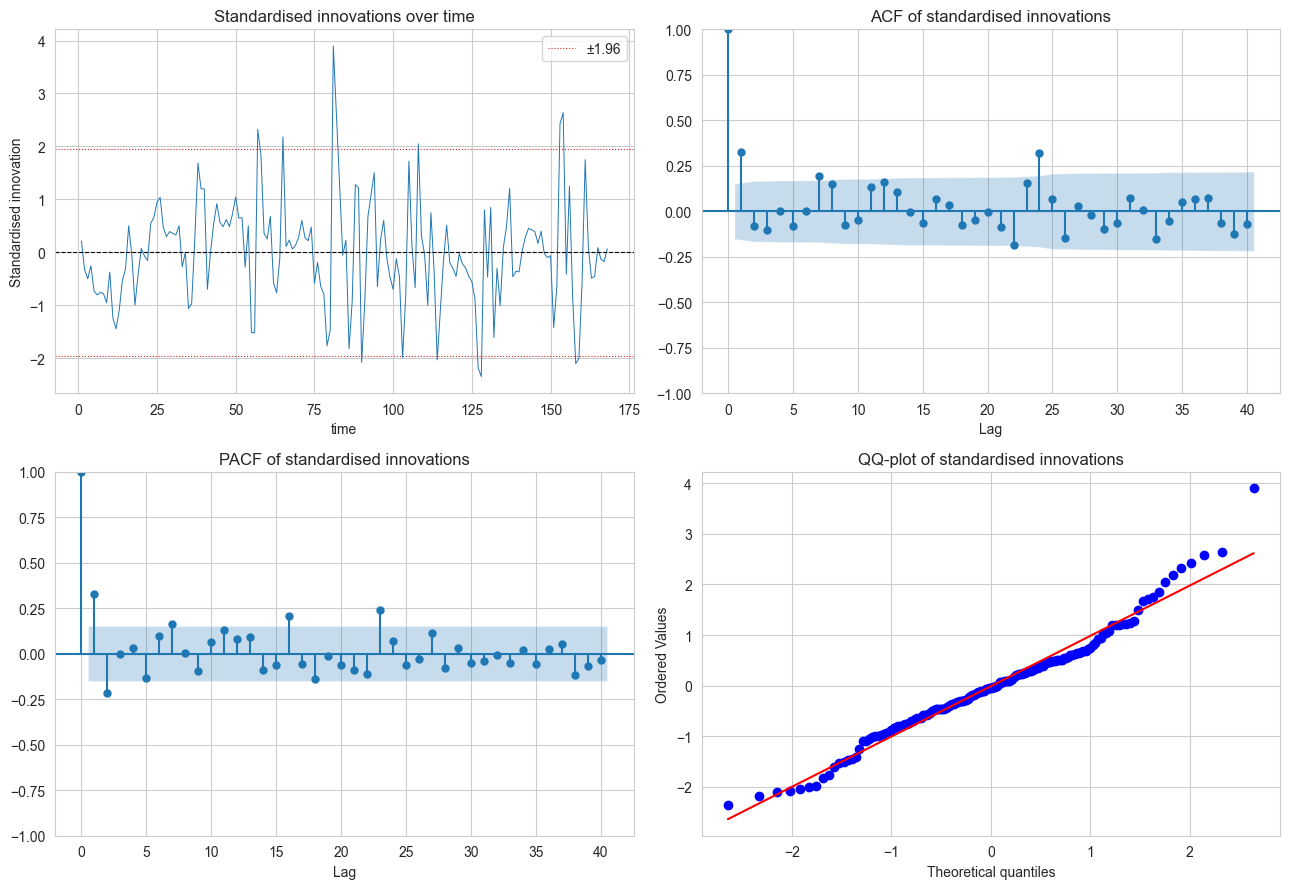

In [26]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import probplot

# --- Run filter at estimated parameters to get innovations ---
innovations, S_vals, x_filt = kf_filter(par_hat, Y, U)

# Standardised innovations (should be N(0,1) if model is correct)
std_innov = innovations / np.sqrt(S_vals)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1. Residuals over time
ax = axes[0, 0]
ax.plot(data['time'].values, std_innov, color='C0', linewidth=0.7)
ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
ax.axhline( 1.96, color='C3', linewidth=0.8, linestyle=':', label='±1.96')
ax.axhline(-1.96, color='C3', linewidth=0.8, linestyle=':')
ax.set_title('Standardised innovations over time')
ax.set_xlabel('time');  ax.set_ylabel('Standardised innovation')
ax.legend()

# 2. ACF of standardised innovations
plot_acf(std_innov, lags=40, ax=axes[0, 1], title='ACF of standardised innovations')
axes[0, 1].set_xlabel('Lag')

# 3. PACF of standardised innovations
plot_pacf(std_innov, lags=40, ax=axes[1, 0],
          title='PACF of standardised innovations', method='ywm')
axes[1, 0].set_xlabel('Lag')

# 4. QQ-plot
probplot(std_innov, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('QQ-plot of standardised innovations')

plt.tight_layout()
plt.show()

In [ ]:
# --- Filtered state vs observed ---
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(data['time'].values, Y,      color='C0', linewidth=0.8, label='Observed $Y_t$')
ax.plot(data['time'].values, x_filt, color='C1', linewidth=0.8, label='Filtered state $\hat{X}_{t|t}$')
ax.set_title('Observed vs. filtered state')
ax.set_xlabel('time');  ax.set_ylabel('Temperature (°C)')
ax.legend()
plt.tight_layout()
plt.show()